# Project 5 — Shortage vs Excess Monetization Engine

**Main question:** What is the expected financial impact of shortage versus excess inventory?

**System flow:** `Forecast Accuracy → Safety Stock → Reorder Point → Fill Rate → [Project 5] → ROI`

---

## Sections
1. Load data and Project 4 service results
2. Estimate expected units short and excess per SKU-location
3. Calculate shortage cost
4. Calculate excess cost
5. Combined risk ranking
6. Scenario analysis (base / optimistic / pessimistic)
7. Business summary and recommendations

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import norm

from src.monetization import shortage_cost, excess_cost, expected_loss

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.2f}".format)

# Use processed (real) data if available, else fall back to sample (synthetic)
_processed = ROOT / "data" / "processed" / "master_data.csv"
_sample    = ROOT / "data" / "sample"    / "master_data.csv"
DATA = _processed if _processed.exists() else _sample
print(f"Data source: {DATA.relative_to(ROOT)}")
P4   = ROOT / "outputs" / "tables" / "04_fill_rate_results.csv"
OUT  = ROOT / "outputs"
FIG  = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

WEEKS_PER_YEAR   = 52
MARKDOWN_RATE    = 0.20   # 20% markdown on excess units
EXPEDITE_MULT    = 0.30   # expedite cost = 30% of unit margin

print("Root:", ROOT)

Data source: data\processed\master_data.csv
Root: C:\Users\simba\OneDrive\Dokumenter\Dev\supply-chain-uncertainty-system


---
## 1. Load data and Project 4 service results

In [2]:
df = pd.read_csv(DATA, parse_dates=["date"])
p4 = pd.read_csv(P4)

# Financial fields from master data
financials = (
    df
    .groupby(["sku", "location"])
    .agg(
        unit_cost=("unit_cost", "first"),
        unit_margin=("unit_margin", "first"),
        holding_cost_rate=("holding_cost_rate", "first"),
        shortage_cost_pu=("shortage_cost_per_unit", "first"),
        avg_on_hand=("on_hand", "mean"),
    )
    .reset_index()
)

mon = p4.merge(financials, on=["sku", "location"])

# Annual demand
mon["annual_demand"] = mon["avg_weekly_demand"] * WEEKS_PER_YEAR

print(f"{len(mon)} SKU-locations loaded")
mon[["sku", "location", "abc_class", "fill_rate_sim", "csl_sim",
     "unit_cost", "unit_margin", "holding_cost_rate", "shortage_cost_pu"]].head(4)

300 SKU-locations loaded


,sku,location,abc_class,fill_rate_sim,csl_sim,unit_cost,unit_margin,holding_cost_rate,shortage_cost_pu
0,SKU_A01,Store_North,A,1.00,1.00,1.25,0.38,0.20,0.57
1,SKU_B03,Store_Central,A,1.00,1.00,2.50,0.75,0.20,1.12
2,SKU_A01,Store_Central,A,1.00,1.00,1.25,0.38,0.20,0.57
3,SKU_A05,Store_Central,A,1.00,1.00,1.10,0.33,0.20,0.50


---
## 2. Estimate expected units short and excess

**Units short per year:**
$$\text{shortage}_y = (1 - FR) \times \text{annual demand}$$

**Excess units (avg on-hand above recommended SS):**
$$\text{excess} = \max(\text{avg on-hand} - \text{rec\_ss},\; 0)$$

In [3]:
# Shortage volume
mon["units_short_annual"] = (1 - mon["fill_rate_sim"]) * mon["annual_demand"]

# Stockout probability = 1 - CSL
mon["stockout_prob"] = 1 - mon["csl_sim"]

# Excess volume: on-hand above recommended safety stock
mon["excess_units"] = (mon["avg_on_hand"] - mon["rec_ss"]).clip(lower=0)

# Excess probability: fraction of weeks where on-hand > rec_ss
# Approximate as complement of stockout probability weighted by fill rate
mon["excess_prob"] = mon["fill_rate_sim"]  # SKUs with high FR likely have excess

print("Volume summary:")
print(f"  Total units short (annual):  {mon['units_short_annual'].sum():>10,.0f}")
print(f"  Total excess units (avg):    {mon['excess_units'].sum():>10,.0f}")
print()
print("By ABC class:")
print(
    mon.groupby("abc_class")[["units_short_annual", "excess_units"]]
    .sum()
    .round(0)
    .to_string()
)

Volume summary:
  Total units short (annual):           0
  Total excess units (avg):         8,012

By ABC class:
           units_short_annual  excess_units
abc_class                                  
A                        0.00       6669.00
B                        0.00       1099.00
C                        0.00        244.00


---
## 3. Calculate shortage cost

$$\text{Shortage cost} = \text{units short} \times (\text{unit margin} + \text{expedite cost per unit})$$

Expedite cost = fraction of margin (represents air freight, premium sourcing, customer penalties).

In [4]:
mon["expedite_cost_pu"]   = mon["unit_margin"] * EXPEDITE_MULT
mon["shortage_cost_annual"] = mon.apply(
    lambda r: shortage_cost(
        r["units_short_annual"],
        r["unit_margin"],
        r["expedite_cost_pu"],
    ),
    axis=1,
)

# Expected shortage cost (weighted by stockout probability)
mon["exp_shortage_cost"] = mon["stockout_prob"] * mon["shortage_cost_annual"]

print("Shortage cost summary (CHF):")
print(f"  Total gross shortage cost:    CHF {mon['shortage_cost_annual'].sum():>12,.0f}")
print(f"  Total expected shortage cost: CHF {mon['exp_shortage_cost'].sum():>12,.0f}")
print()
print("Top 5 SKU-locations by expected shortage cost:")
top5_short = mon.nlargest(5, "exp_shortage_cost")[["sku", "location", "abc_class",
    "fill_rate_sim", "units_short_annual", "exp_shortage_cost"]]
print(top5_short.to_string(index=False))

Shortage cost summary (CHF):
  Total gross shortage cost:    CHF            0
  Total expected shortage cost: CHF            0

Top 5 SKU-locations by expected shortage cost:
    sku      location abc_class  fill_rate_sim  units_short_annual  exp_shortage_cost
SKU_A01   Store_North         A           1.00                0.00               0.00
SKU_B03 Store_Central         A           1.00                0.00               0.00
SKU_A01 Store_Central         A           1.00                0.00               0.00
SKU_A05 Store_Central         A           1.00                0.00               0.00
SKU_A11   Store_North         A           1.00                0.00               0.00


---
## 4. Calculate excess cost

$$\text{Excess cost} = \text{excess units} \times \text{unit cost} \times \text{holding rate} + \text{markdown loss}$$

Markdown loss = fraction of excess inventory written down or sold at a discount.

In [5]:
mon["excess_cost_annual"] = mon.apply(
    lambda r: excess_cost(
        r["excess_units"],
        r["unit_cost"],
        r["holding_cost_rate"],
        periods=1.0,
        markdown_rate=MARKDOWN_RATE,
    ),
    axis=1,
)

# Expected excess cost (weighted by excess probability)
mon["exp_excess_cost"] = mon["excess_prob"] * mon["excess_cost_annual"]

print("Excess cost summary (CHF):")
print(f"  Total gross excess cost:    CHF {mon['excess_cost_annual'].sum():>12,.0f}")
print(f"  Total expected excess cost: CHF {mon['exp_excess_cost'].sum():>12,.0f}")
print()
print("Top 5 SKU-locations by expected excess cost:")
top5_exc = mon.nlargest(5, "exp_excess_cost")[["sku", "location", "abc_class",
    "excess_units", "unit_cost", "exp_excess_cost"]]
print(top5_exc.to_string(index=False))

Excess cost summary (CHF):
  Total gross excess cost:    CHF        9,150
  Total expected excess cost: CHF        9,150

Top 5 SKU-locations by expected excess cost:
    sku      location abc_class  excess_units  unit_cost  exp_excess_cost
SKU_C07   Store_North         A         17.44      12.00            83.69
SKU_C02 Store_Central         A         22.01       8.20            72.20
SKU_B03 Store_Central         A         70.16       2.50            70.16
SKU_C07 Store_Central         A         13.39      12.00            64.28
SKU_C07    Store_East         A         13.11      12.00            62.92


---
## 5. Combined risk ranking

In [6]:
mon["total_expected_loss"] = mon["exp_shortage_cost"] + mon["exp_excess_cost"]

mon["risk_type"] = mon.apply(
    lambda r: "Shortage-dominated" if r["exp_shortage_cost"] > r["exp_excess_cost"]
    else "Excess-dominated",
    axis=1,
)

print("Risk type split:")
print(mon["risk_type"].value_counts().to_string())
print()
print(f"Total expected loss:  CHF {mon['total_expected_loss'].sum():>12,.0f}")
print(f"  from shortage:      CHF {mon['exp_shortage_cost'].sum():>12,.0f}")
print(f"  from excess:        CHF {mon['exp_excess_cost'].sum():>12,.0f}")

Risk type split:
risk_type
Excess-dominated    300

Total expected loss:  CHF        9,150
  from shortage:      CHF            0
  from excess:        CHF        9,150


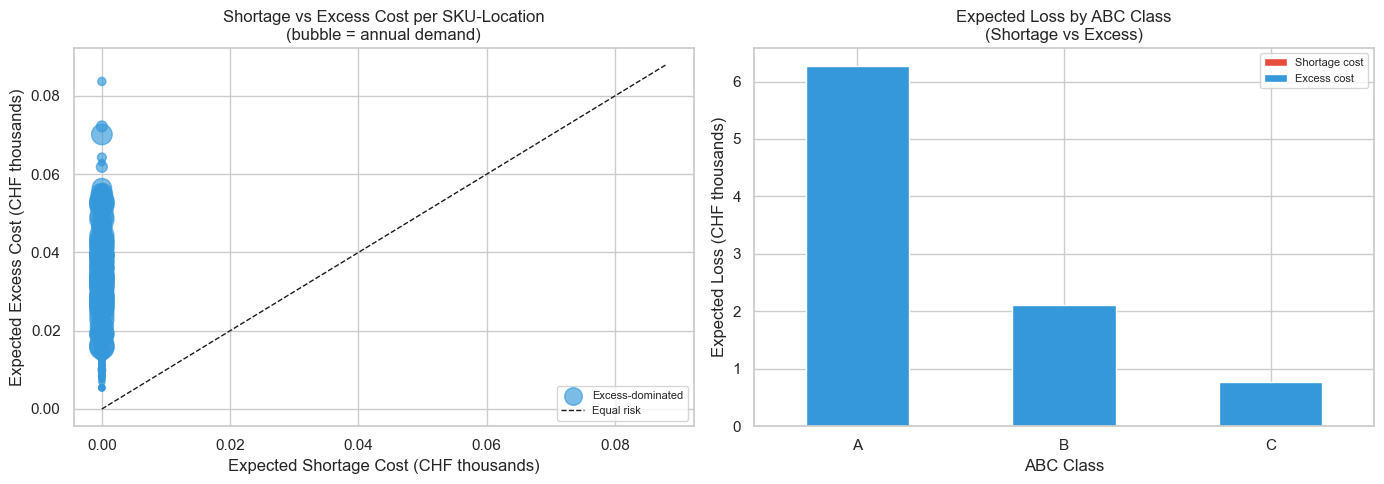

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bubble chart: shortage vs excess cost, sized by annual demand
risk_colors = {"Shortage-dominated": "#e74c3c", "Excess-dominated": "#3498db"}
for rtype, grp in mon.groupby("risk_type"):
    axes[0].scatter(
        grp["exp_shortage_cost"] / 1000,
        grp["exp_excess_cost"] / 1000,
        s=np.clip(grp["annual_demand"] / 20, 20, 300),
        color=risk_colors[rtype],
        alpha=0.65,
        label=rtype,
    )
max_val = max(mon["exp_shortage_cost"].max(), mon["exp_excess_cost"].max()) / 1000 * 1.05
axes[0].plot([0, max_val], [0, max_val], "k--", linewidth=1, label="Equal risk")
axes[0].set_xlabel("Expected Shortage Cost (CHF thousands)")
axes[0].set_ylabel("Expected Excess Cost (CHF thousands)")
axes[0].set_title("Shortage vs Excess Cost per SKU-Location\n(bubble = annual demand)")
axes[0].legend(fontsize=8)

# Stacked bar: total expected loss by ABC class
loss_by_abc = mon.groupby("abc_class")[["exp_shortage_cost", "exp_excess_cost"]].sum() / 1000
loss_by_abc.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#e74c3c", "#3498db"],
    edgecolor="white",
)
axes[1].set_xlabel("ABC Class")
axes[1].set_ylabel("Expected Loss (CHF thousands)")
axes[1].set_title("Expected Loss by ABC Class\n(Shortage vs Excess)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Shortage cost", "Excess cost"], fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "05a_shortage_vs_excess.png", dpi=150)
plt.show()

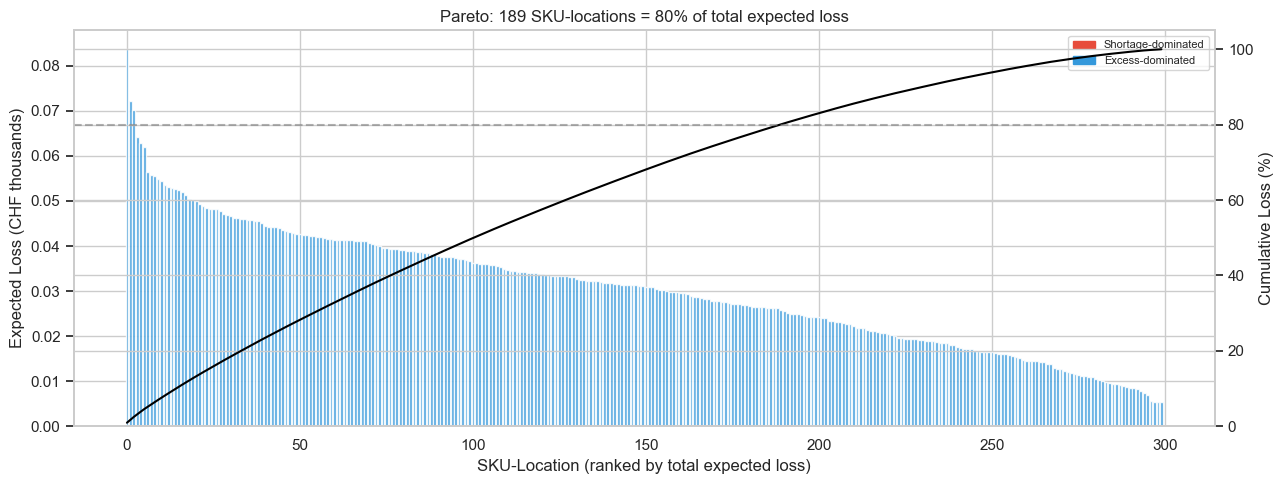

Top 189 SKU-locations drive 80% of expected loss


In [8]:
# Pareto: top SKUs by total expected loss
ranked = mon.sort_values("total_expected_loss", ascending=False).reset_index(drop=True)
ranked["cum_loss_pct"] = ranked["total_expected_loss"].cumsum() / ranked["total_expected_loss"].sum()
n80 = (ranked["cum_loss_pct"] <= 0.80).sum()

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    range(len(ranked)),
    ranked["total_expected_loss"] / 1000,
    color=ranked["risk_type"].map(risk_colors),
    alpha=0.85,
)
ax2 = ax.twinx()
ax2.plot(
    range(len(ranked)),
    ranked["cum_loss_pct"] * 100,
    color="black", linewidth=1.5, label="Cumulative %",
)
ax2.axhline(80, color="gray", linestyle="--", alpha=0.6)
ax2.set_ylabel("Cumulative Loss (%)")
ax2.set_ylim(0, 105)

ax.set_xlabel("SKU-Location (ranked by total expected loss)")
ax.set_ylabel("Expected Loss (CHF thousands)")
ax.set_title(f"Pareto: {n80} SKU-locations = 80% of total expected loss")

patches = [
    plt.matplotlib.patches.Patch(color="#e74c3c", label="Shortage-dominated"),
    plt.matplotlib.patches.Patch(color="#3498db", label="Excess-dominated"),
]
ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "05b_pareto_loss.png", dpi=150)
plt.show()
print(f"Top {n80} SKU-locations drive 80% of expected loss")

---
## 6. Scenario analysis: base / optimistic / pessimistic

Tests how sensitive total expected loss is to the key cost assumptions.

In [9]:
scenarios = {
    "Pessimistic": {"expedite_mult": 0.50, "markdown_rate": 0.30, "margin_mult": 1.20},
    "Base":        {"expedite_mult": 0.30, "markdown_rate": 0.20, "margin_mult": 1.00},
    "Optimistic":  {"expedite_mult": 0.15, "markdown_rate": 0.10, "margin_mult": 0.80},
}

scenario_results = []
for name, params in scenarios.items():
    exp_pu = mon["unit_margin"] * params["expedite_mult"]
    sc_short = shortage_cost(
        mon["units_short_annual"],
        mon["unit_margin"] * params["margin_mult"],
        exp_pu,
    ) * mon["stockout_prob"]

    sc_excess = excess_cost(
        mon["excess_units"],
        mon["unit_cost"],
        mon["holding_cost_rate"],
        markdown_rate=params["markdown_rate"],
    ) * mon["excess_prob"]

    scenario_results.append({
        "Scenario":              name,
        "Shortage Cost (KCHF)": sc_short.sum() / 1000,
        "Excess Cost (KCHF)":   sc_excess.sum() / 1000,
        "Total Loss (KCHF)":    (sc_short + sc_excess).sum() / 1000,
    })

scen_df = pd.DataFrame(scenario_results)
print(scen_df.to_string(index=False))

   Scenario  Shortage Cost (KCHF)  Excess Cost (KCHF)  Total Loss (KCHF)
Pessimistic                  0.00               11.44              11.44
       Base                  0.00                9.15               9.15
 Optimistic                  0.00                6.86               6.86


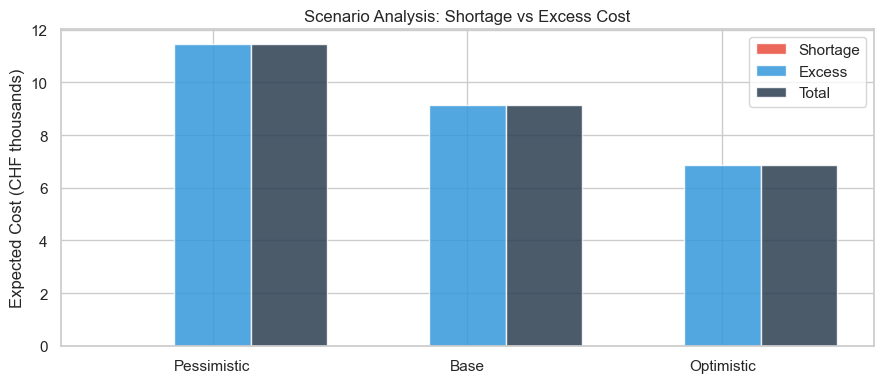

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(scen_df))
w = 0.30
ax.bar(x - w, scen_df["Shortage Cost (KCHF)"], w, label="Shortage", color="#e74c3c", alpha=0.85)
ax.bar(x,     scen_df["Excess Cost (KCHF)"],   w, label="Excess",   color="#3498db", alpha=0.85)
ax.bar(x + w, scen_df["Total Loss (KCHF)"],    w, label="Total",    color="#2c3e50", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(scen_df["Scenario"])
ax.set_ylabel("Expected Cost (CHF thousands)")
ax.set_title("Scenario Analysis: Shortage vs Excess Cost")
ax.legend()

plt.tight_layout()
plt.savefig(FIG / "05c_scenario_analysis.png", dpi=150)
plt.show()

---
## 7. Business summary and recommendations

In [11]:
def recommend(row) -> str:
    if row["risk_type"] == "Shortage-dominated" and row["abc_class"] == "A":
        return "Increase SS or expedite — high-value shortage risk"
    elif row["risk_type"] == "Shortage-dominated" and row["total_expected_loss"] > 5000:
        return "Increase SS — material shortage cost"
    elif row["risk_type"] == "Excess-dominated" and row["abc_class"] == "C":
        return "Reduce SS and ROP — trapped capital on low-value item"
    elif row["risk_type"] == "Excess-dominated" and row["exp_excess_cost"] > 5000:
        return "Reduce excess — material holding and markdown cost"
    elif row["risk_type"] == "Shortage-dominated":
        return "Monitor shortage risk"
    return "Monitor excess — low financial impact"

mon["recommendation"] = mon.apply(recommend, axis=1)

print("Recommendation summary:")
print(mon["recommendation"].value_counts().to_string())

Recommendation summary:
recommendation
Monitor excess — low financial impact                    245
Reduce SS and ROP — trapped capital on low-value item     55


In [12]:
output_cols = [
    "sku", "location", "abc_class", "xyz_class", "segment",
    "avg_weekly_demand", "annual_demand",
    "unit_cost", "unit_margin",
    "fill_rate_sim", "csl_sim", "stockout_prob",
    "units_short_annual", "excess_units",
    "exp_shortage_cost", "exp_excess_cost", "total_expected_loss",
    "risk_type", "recommendation",
]
output = mon[output_cols].sort_values("total_expected_loss", ascending=False)
output.to_csv(OUT / "tables" / "05_monetization_results.csv", index=False)
print("Saved results table.")
output.head(10)

Saved results table.


,sku,location,abc_class,xyz_class,segment,avg_weekly_demand,annual_demand,unit_cost,unit_margin,fill_rate_sim,csl_sim,stockout_prob,units_short_annual,excess_units,exp_shortage_cost,exp_excess_cost,total_expected_loss,risk_type,recommendation
117,SKU_C07,Store_North,A,Z,A/Z,13.27,689.87,12.00,3.60,1.00,1.00,0.00,0.00,17.44,0.00,83.69,83.69,Excess-dominated,Monitor excess — low financial impact
92,SKU_C02,Store_Central,A,Y,A/Y,23.57,1225.47,8.20,2.46,1.00,1.00,0.00,0.00,22.01,0.00,72.20,72.20,Excess-dominated,Monitor excess — low financial impact
1,SKU_B03,Store_Central,A,Y,A/Y,83.91,4363.56,2.50,0.75,1.00,1.00,0.00,0.00,70.16,0.00,70.16,70.16,Excess-dominated,Monitor excess — low financial impact
115,SKU_C07,Store_Central,A,Z,A/Z,15.66,814.23,12.00,3.60,1.00,1.00,0.00,0.00,13.39,0.00,64.28,64.28,Excess-dominated,Monitor excess — low financial impact
116,SKU_C07,Store_East,A,Z,A/Z,8.72,453.27,12.00,3.60,1.00,1.00,0.00,0.00,13.11,0.00,62.92,62.92,Excess-dominated,Monitor excess — low financial impact
141,SKU_C01,Store_North,A,Y,A/Y,23.87,1241.07,7.50,2.25,1.00,1.00,0.00,0.00,20.63,0.00,61.88,61.88,Excess-dominated,Monitor excess — low financial impact
38,SKU_A12,Store_West,A,X,A/X,74.65,3881.78,2.20,0.66,1.00,1.00,0.00,0.00,64.14,0.00,56.44,56.44,Excess-dominated,Monitor excess — low financial impact
154,SKU_C01,Store_Central,A,Y,A/Y,30.07,1563.47,7.50,2.25,1.00,1.00,0.00,0.00,18.61,0.00,55.83,55.83,Excess-dominated,Monitor excess — low financial impact
28,SKU_B06,Store_East,A,Y,A/Y,45.37,2359.02,3.20,0.96,1.00,1.00,0.00,0.00,43.42,0.00,55.58,55.58,Excess-dominated,Monitor excess — low financial impact
35,SKU_A03,Store_West,A,X,A/X,90.72,4717.63,2.10,0.63,1.00,1.00,0.00,0.00,65.42,0.00,54.95,54.95,Excess-dominated,Monitor excess — low financial impact


In [13]:
print("===== MONETIZATION SUMMARY =====")
print(f"SKU-locations assessed:           {len(mon)}")
print(f"Shortage-dominated:               {(mon['risk_type']=='Shortage-dominated').sum()}")
print(f"Excess-dominated:                 {(mon['risk_type']=='Excess-dominated').sum()}")
print()
print(f"Total expected shortage cost:     CHF {mon['exp_shortage_cost'].sum():>12,.0f}")
print(f"Total expected excess cost:       CHF {mon['exp_excess_cost'].sum():>12,.0f}")
print(f"Total expected loss:              CHF {mon['total_expected_loss'].sum():>12,.0f}")
print()
n80 = (ranked["cum_loss_pct"] <= 0.80).sum()
print(f"Top {n80} SKU-locations = 80% of total loss")
print()
print("These cost estimates feed directly into Project 6 (ROI Comparator).")
print("Annual saving per lever = reduction in total expected loss.")

===== MONETIZATION SUMMARY =====
SKU-locations assessed:           300
Shortage-dominated:               0
Excess-dominated:                 300

Total expected shortage cost:     CHF            0
Total expected excess cost:       CHF        9,150
Total expected loss:              CHF        9,150

Top 189 SKU-locations = 80% of total loss

These cost estimates feed directly into Project 6 (ROI Comparator).
Annual saving per lever = reduction in total expected loss.
